<h1>Borrador de Arturo </h1>

In [25]:
%load_ext autoreload
%autoreload 2
import sys
import os 
import networkx as nx 
from matplotlib import pyplot as plt
#Codigo para importar grafos y logica pues estan en una carpeta afuera
ruta_proyecto = r"C:\Users\Arturo\Documents\Proyecto LCC\proyecto-logica-G5"
# Si no está en el sistema se agrega.
if ruta_proyecto not in sys.path:
    sys.path.append(ruta_proyecto)

# Como ya está en el sistema ya se podría importar
try:
    from logica import*   
    print(" Módulo lógica cargado exitosamente")
except ModuleNotFoundError:
    print(" No se encontró el archivo. Revisa que el nombre sea correcto.") 
try:
    from grafos import*
    print(" Módulo grafos cargado exitosamente")
except ModuleNotFoundError:
    print(" No se encontró el archivo. Revisa que el nombre sea correcto.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 Módulo lógica cargado exitosamente
 Módulo grafos cargado exitosamente


In [26]:
g = Grafos()

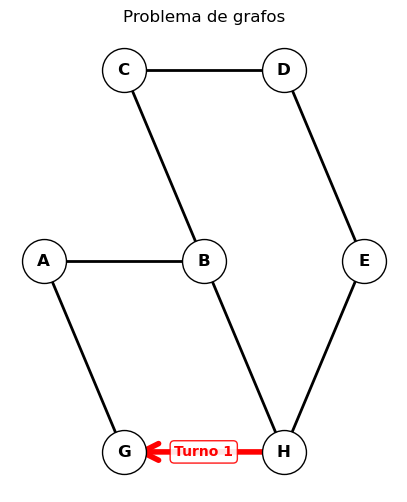

In [27]:
a1 = g.To.ravel([("H","G"),1]) 
I = {a1:True}    
g.visualizar_grafo(I) 



In [28]:
g.recorridos

[('H', 'G'),
 ('G', 'H'),
 ('H', 'B'),
 ('B', 'H'),
 ('H', 'E'),
 ('E', 'H'),
 ('G', 'A'),
 ('A', 'G'),
 ('A', 'B'),
 ('B', 'A'),
 ('B', 'C'),
 ('C', 'B'),
 ('C', 'D'),
 ('D', 'C'),
 ('D', 'E'),
 ('E', 'D')]

<h2>REGLA 1</h2>

In [29]:
h_conec = [(a,b) for (a,b) in g.recorridos if a=='H'] 
print(h_conec)
formula_final = []
t = 0 

formula_final = ""

for recorrido in h_conec: 
    # 1. La SEMILLA de la cebolla es el movimiento actual de H
    # No lleva "-" porque este es el que "ocurre"
    formula_actual = g.To.ravel([recorrido, t])
    
    # 2. Filtramos los otros movimientos
    otros_movimientos = [m for m in g.recorridos if m != recorrido]    
    
    # 3. CONSTRUCCIÓN DE LA CEBOLLA
    # En cada paso, envolvemos lo anterior con una nueva capa
    for mov in otros_movimientos: 
        # (Fórmula_Anterior Y -Nuevo_Movimiento)
        formula_actual = "(" + formula_actual + "Y-" + g.To.ravel([mov, t]) + ")"
    
    # Añadimos la cebolla completa a nuestra lista de bloques 
    if formula_final =="":
        formula_final = formula_actual 
    else:
        formula_final = "(" + formula_final + "O" + formula_actual + ")"

print(formula_final)

[('H', 'G'), ('H', 'B'), ('H', 'E')]
(((((((((((((((((ĀY-ā)Y-Ă)Y-ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď)O(((((((((((((((ĂY-Ā)Y-ā)Y-ă)Y-Ą)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď))O(((((((((((((((ĄY-Ā)Y-ā)Y-Ă)Y-ă)Y-ą)Y-Ć)Y-ć)Y-Ĉ)Y-ĉ)Y-Ċ)Y-ċ)Y-Č)Y-č)Y-Ď)Y-ď))


In [30]:
%time
formula1 = inorder_to_tree(formula_final)

CPU times: total: 0 ns
Wall time: 8.82 μs


In [32]:
I = formula1.SATtableaux_backtracking()

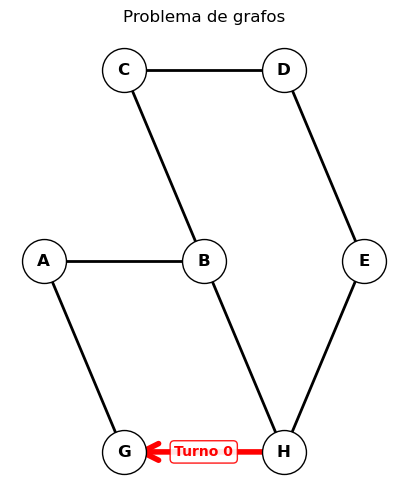

In [33]:
g.visualizar_grafo(I)